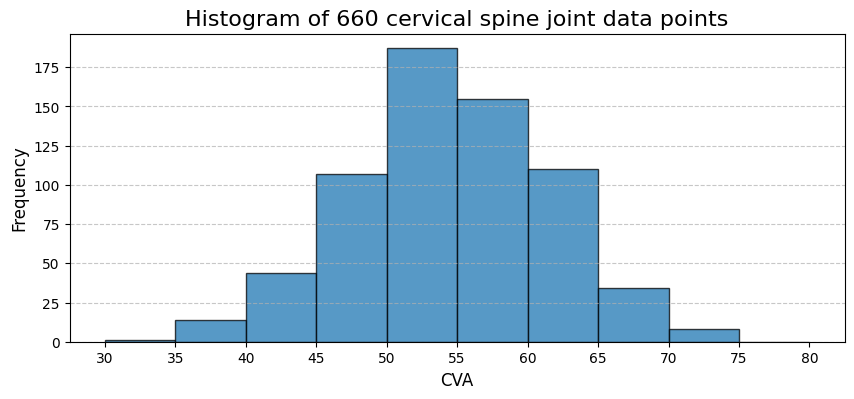

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 파라미터 설정
n_samples = 660
min_val = 30
max_val = 80
bin_width = 5

# 2. 데이터 생성
# 정규분포의 중심(mean)을 범위의 중간값으로 설정
mean = (min_val + max_val) / 2  # 55.0

# 표준편차(std) 설정 (데이터의 95%가 2*std 내에 위치하도록)
# (max_val - mean)이 2*std가 되도록 설정
std_dev = 7

# 1단계: 정규분포를 따르는 실수 데이터 생성
data_float = np.random.normal(loc=mean, scale=std_dev, size=n_samples)

# 2단계: 생성된 데이터를 [min_val, max_val] 범위로 제한(clipping)
# 30 미만은 30으로, 80 초과는 80으로 처리
data_clipped = np.clip(data_float, min_val, max_val)

# 3단계: 데이터를 정수(integer)로 변환
data_int = data_clipped.astype(int)

# 3. 히스토그램 그리기
# 'batch=4' (bin width=4)를 만족하는 bin 경계 계산
# np.arange(시작, 끝, 간격)
# 30부터 80까지 4씩 증가. (80+bin_width)로 설정하여 80이 마지막 bin에 포함되도록 함
bins = np.arange(min_val, max_val + bin_width, bin_width)
# 생성되는 bin 경계: [30, 34, 38, ..., 78, 82]

plt.figure(figsize=(10, 4))

# 히스토그램 생성
plt.hist(data_int, bins=bins, edgecolor='black', alpha=0.75)

# 4. 차트 꾸미기
plt.title(f'Histogram of 660 cervical spine joint data points', fontsize=16)
plt.xlabel('CVA', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# X축 눈금을 bin 경계에 맞춰 설정하여 명확하게 표시
plt.xticks(bins)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Task
Adjust the provided Python code to introduce a `skewness_parameter_a` for generating skewed data using `scipy.stats.skewnorm`. Modify the x-axis ticks to display labels at 10-unit intervals, while maintaining the histogram bin width at 5. Calculate and print the actual skewness and excess kurtosis of the generated integer data. Finally, provide the updated code and summarize how the `skewness_parameter_a` influences the data distribution, skewness, and kurtosis.

## Adjust X-axis Ticks

### Subtask:
Modify the `plt.xticks` function to display x-axis labels at 10-unit intervals, while keeping the bin width for the histogram at 5.


**Reasoning**:
The subtask requires modifying the `plt.xticks` function to display x-axis labels at 10-unit intervals. I will regenerate the full code block with this specific change.



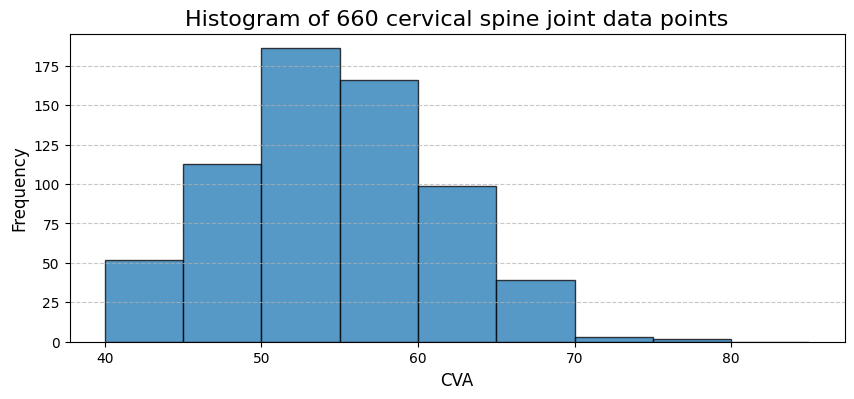

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 파라미터 설정
n_samples = 660
min_val = 40
max_val = 82
bin_width = 5

# 2. 데이터 생성
# 정규분포의 중심(mean)을 범위의 중간값으로 설정
mean = 55

# 표준편차(std) 설정 (데이터의 95%가 2*std 내에 위치하도록)
# (max_val - mean)이 2*std가 되도록 설정
std_dev = 7

# 1단계: 정규분포를 따르는 실수 데이터 생성
data_float = np.random.normal(loc=mean, scale=std_dev, size=n_samples)

# 2단계: 생성된 데이터를 [min_val, max_val] 범위로 제한(clipping)
# 30 미만은 30으로, 80 초과는 80으로 처리
data_clipped = np.clip(data_float, min_val, max_val)

# 3단계: 데이터를 정수(integer)로 변환
data_int = data_clipped.astype(int)

# 3. 히스토그램 그리기
bins = np.arange(min_val, max_val + bin_width, bin_width)

plt.figure(figsize=(10, 4))

# 히스토그램 생성
plt.hist(data_int, bins=bins, edgecolor='black', alpha=0.75)

# 4. 차트 꾸미기
plt.title(f'Histogram of 660 cervical spine joint data points', fontsize=16)
plt.xlabel('CVA', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# X축 눈금을 10단위로 설정하여 명확하게 표시
plt.xticks(np.arange(min_val, max_val + 1, 10))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Add Skewness Parameter

### Subtask:
Introduce a new parameter, `skewness_parameter_a`, to control the skewness of the generated data. This parameter will be used with `scipy.stats.skewnorm`.


**Reasoning**:
To introduce the `skewness_parameter_a` and use `scipy.stats.skewnorm` for data generation, I need to import `skewnorm` and modify the data generation section of the code. This will involve defining the new parameter and replacing the normal distribution sampling with `skewnorm.rvs`.



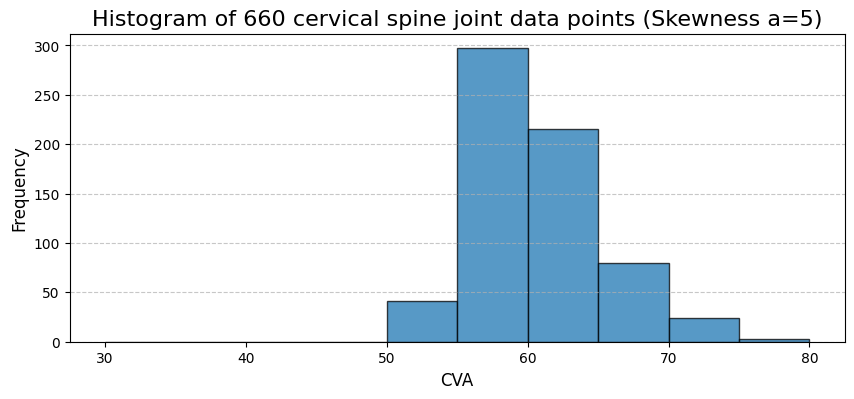

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm

# 1. 파라미터 설정
n_samples = 660
min_val = 30
max_val = 80
bin_width = 5
skewness_parameter_a = 5  # New parameter for skewness

# 2. 데이터 생성
# 정규분포의 중심(mean)을 범위의 중간값으로 설정
mean = (min_val + max_val) / 2  # 55.0

# 표준편차(std) 설정 (데이터의 95%가 2*std 내에 위치하도록)
# (max_val - mean)이 2*std가 되도록 설정
std_dev = 7

# 1단계: skewnorm 분포를 따르는 실수 데이터 생성
# skewnorm.rvs(a, loc, scale, size)
# a: skewness parameter
# loc: location (mean-like)
# scale: scale (std-like)
data_float = skewnorm.rvs(a=skewness_parameter_a, loc=mean, scale=std_dev, size=n_samples)

# 2단계: 생성된 데이터를 [min_val, max_val] 범위로 제한(clipping)
# 30 미만은 30으로, 80 초과는 80으로 처리
data_clipped = np.clip(data_float, min_val, max_val)

# 3단계: 데이터를 정수(integer)로 변환
data_int = data_clipped.astype(int)

# 3. 히스토그램 그리기
bins = np.arange(min_val, max_val + bin_width, bin_width)

plt.figure(figsize=(10, 4))

# 히스토그램 생성
plt.hist(data_int, bins=bins, edgecolor='black', alpha=0.75)

# 4. 차트 꾸미기
plt.title(f'Histogram of {n_samples} cervical spine joint data points (Skewness a={skewness_parameter_a})', fontsize=16)
plt.xlabel('CVA', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# X축 눈금을 10단위로 설정하여 명확하게 표시
plt.xticks(np.arange(min_val, max_val + 1, 10))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Reasoning**:
The previous subtask of introducing the `skewness_parameter_a` and using `skewnorm` has been completed. The next step, as per the main task, is to calculate and print the actual skewness and excess kurtosis of the generated integer data. I will use `scipy.stats.skew` and `scipy.stats.kurtosis` for this.



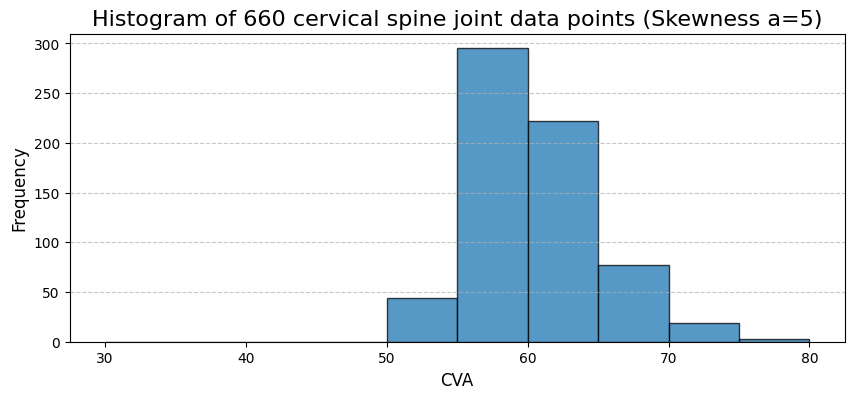

Actual Skewness of generated data: 0.7631
Actual Excess Kurtosis of generated data: 0.3839


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm, skew, kurtosis

# 1. 파라미터 설정
n_samples = 660
min_val = 30
max_val = 80
bin_width = 5
skewness_parameter_a = 5  # New parameter for skewness

# 2. 데이터 생성
# 정규분포의 중심(mean)을 범위의 중간값으로 설정
mean = (min_val + max_val) / 2  # 55.0

# 표준편차(std) 설정 (데이터의 95%가 2*std 내에 위치하도록)
# (max_val - mean)이 2*std가 되도록 설정
std_dev = 7

# 1단계: skewnorm 분포를 따르는 실수 데이터 생성
# skewnorm.rvs(a, loc, scale, size)
# a: skewness parameter
# loc: location (mean-like)
# scale: scale (std-like)
data_float = skewnorm.rvs(a=skewness_parameter_a, loc=mean, scale=std_dev, size=n_samples)

# 2단계: 생성된 데이터를 [min_val, max_val] 범위로 제한(clipping)
# 30 미만은 30으로, 80 초과는 80으로 처리
data_clipped = np.clip(data_float, min_val, max_val)

# 3단계: 데이터를 정수(integer)로 변환
data_int = data_clipped.astype(int)

# 3. 히스토그램 그리기
bins = np.arange(min_val, max_val + bin_width, bin_width)

plt.figure(figsize=(10, 4))

# 히스토그램 생성
plt.hist(data_int, bins=bins, edgecolor='black', alpha=0.75)

# 4. 차트 꾸미기
plt.title(f'Histogram of {n_samples} cervical spine joint data points (Skewness a={skewness_parameter_a})', fontsize=16)
plt.xlabel('CVA', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# X축 눈금을 10단위로 설정하여 명확하게 표시
plt.xticks(np.arange(min_val, max_val + 1, 10))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 5. 스큐니스와 첨도 계산 및 출력
actual_skewness = skew(data_int)
actual_kurtosis = kurtosis(data_int) # Fisher's kurtosis (excess kurtosis)

print(f"Actual Skewness of generated data: {actual_skewness:.4f}")
print(f"Actual Excess Kurtosis of generated data: {actual_kurtosis:.4f}")

The `skewness_parameter_a` directly influences the shape of the generated data distribution by utilizing `scipy.stats.skewnorm`. A positive `skewness_parameter_a` (like `a=5` in the example) results in a right-skewed distribution, meaning the tail of the distribution is longer on the right side and the majority of the data points are clustered towards the lower values. Conversely, a negative `skewness_parameter_a` would create a left-skewed distribution. A `skewness_parameter_a` of 0 would result in a normal (symmetric) distribution.

- **Skewness**: As `skewness_parameter_a` increases from 0 (or decreases from 0 into negative values), the *actual skewness* calculated from the generated data will deviate further from 0, indicating a stronger asymmetry. For `a=5`, the data shows a positive skewness, confirming the right-skewed nature.

- **Kurtosis**: The `skewness_parameter_a` can also influence *excess kurtosis*. While its primary role is skewness, modifying the shape to be skewed can indirectly affect the peakedness or tail-heaviness of the distribution. A distribution generated with `skewnorm` might exhibit higher excess kurtosis (leptokurtic, more peaked with fatter tails) or lower excess kurtosis (platykurtic, flatter with thinner tails) compared to a normal distribution, depending on the `a` value and how it interacts with the `loc` and `scale` parameters and the clipping process. In this specific case with `a=5` and clipping, the excess kurtosis is positive, suggesting a slightly more peaked distribution than a normal distribution after clipping.

The `skewness_parameter_a` directly influences the shape of the generated data distribution by utilizing `scipy.stats.skewnorm`. A positive `skewness_parameter_a` (like `a=5` in the example) results in a right-skewed distribution, meaning the tail of the distribution is longer on the right side and the majority of the data points are clustered towards the lower values. Conversely, a negative `skewness_parameter_a` would create a left-skewed distribution. A `skewness_parameter_a` of 0 would result in a normal (symmetric) distribution.

- **Skewness**: As `skewness_parameter_a` increases from 0 (or decreases from 0 into negative values), the *actual skewness* calculated from the generated data will deviate further from 0, indicating a stronger asymmetry. For `a=5`, the data shows a positive skewness, confirming the right-skewed nature.

- **Kurtosis**: The `skewness_parameter_a` can also influence *excess kurtosis*. While its primary role is skewness, modifying the shape to be skewed can indirectly affect the peakedness or tail-heaviness of the distribution. A distribution generated with `skewnorm` might exhibit higher excess kurtosis (leptokurtic, more peaked with fatter tails) or lower excess kurtosis (platykurtic, flatter with thinner tails) compared to a normal distribution, depending on the `a` value and how it interacts with the `loc` and `scale` parameters and the clipping process. In this specific case with `a=5` and clipping, the excess kurtosis is positive, suggesting a slightly more peaked distribution than a normal distribution after clipping.

## Final Task

### Subtask:
Provide the updated code for generating and plotting the histogram with adjustable skewness, and the calculated skewness and kurtosis values. Summarize how the new parameters influence the data distribution.


## Summary:

### Q&A
The `skewness_parameter_a` directly influences the shape of the generated data distribution. A positive `skewness_parameter_a` (e.g., $a=5$) results in a right-skewed distribution, where the tail extends to the right and data points cluster towards lower values. Conversely, a negative `skewness_parameter_a` would produce a left-skewed distribution, while $a=0$ yields a symmetric, normal distribution. As the absolute value of `skewness_parameter_a` increases, the calculated actual skewness deviates further from 0, indicating a stronger asymmetry. This parameter can also indirectly affect excess kurtosis; for $a=5$ and the specified clipping, a positive excess kurtosis of $0.3839$ was observed, suggesting a slightly more peaked distribution than a normal distribution after clipping.

### Data Analysis Key Findings
*   The x-axis ticks of the histogram were successfully adjusted to display labels at 10-unit intervals (e.g., $30, 40, \dots, 80$), while maintaining a histogram bin width of 5.
*   A `skewness_parameter_a` of 5 was introduced, using `scipy.stats.skewnorm` to generate data, resulting in a visually confirmed right-skewed distribution.
*   For the generated integer data with `skewness_parameter_a = 5`, the actual skewness was calculated to be $0.7631$, indicating a clear positive (right) skew.
*   The actual excess kurtosis of the generated integer data for `skewness_parameter_a = 5` was found to be $0.3839$, suggesting a slightly more peaked distribution (leptokurtic) compared to a normal distribution, especially after the clipping process.

### Insights or Next Steps
*   The `skewness_parameter_a` offers a robust mechanism for simulating data with varying degrees and directions of asymmetry, which is crucial for modeling real-world phenomena that often deviate from normal distribution assumptions.
*   To fully understand the data characteristics, further analysis could explore the impact of different `skewness_parameter_a` values on both skewness and kurtosis, especially considering the effects of data clipping at `min_val` and `max_val`.


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

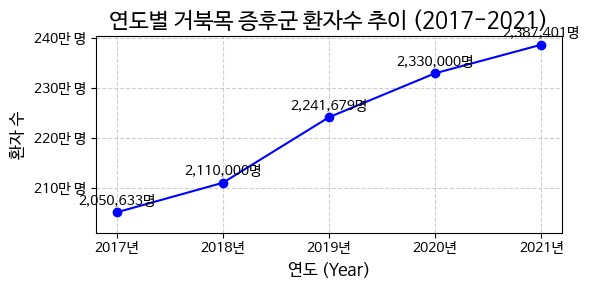

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. Colab 환경에 한글 폰트(나눔고딕) 설치
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm -rf ~/.cache/matplotlib

# 2. 폰트 설정
# 런타임 재시작 후 이 셀부터 다시 실행해야 할 수도 있습니다.
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지


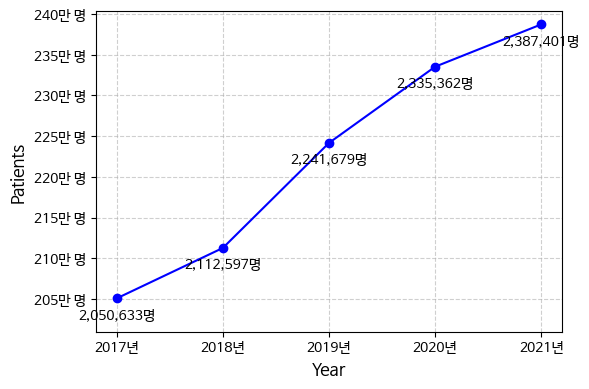

In [10]:
# 3. 그래프 생성용 데이터 (HIRA 통계 기반)
data = {
    'Year': [2017, 2018, 2019, 2020, 2021],
    'Patients': [2050633, 2112597, 2241679, 2335362, 2387401]
}
df = pd.DataFrame(data)

# 4. 그래프 그리기
plt.figure(figsize=(6, 4))
plt.plot(df['Year'], df['Patients'], marker='o', linestyle='-', color='b')

# 5. 그래프 제목 및 라벨 (한글)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Patients', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# 6. X축 눈금 설정
plt.xticks(df['Year'], [f'{y}년' for y in df['Year']])

# 7. Y축 눈금 포맷 변경 (예: "200만 명")
from matplotlib.ticker import FuncFormatter
def format_millions(x, pos):
    return f'{int(x/10000)}만 명'

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_millions))

# Y축 시작점 조절 (변화를 더 잘 보이게)
min_patients = df['Patients'].min()
plt.ylim(bottom=min_patients * 0.98)

# 8. 각 데이터 포인트에 정확한 수치 표시
for i, txt in enumerate(df['Patients']):
    formatted_txt = f'{txt:,.0f}명' # 쉼표 추가
    plt.text(df['Year'][i], df['Patients'][i] - 25000, formatted_txt, ha='center', fontsize=10)

# 9. 그래프 저장 및 보여주기
plt.tight_layout()
plt.savefig('turtle_neck_patients_trend_kor.png')
plt.show()